## **Load the dataset**

In [1]:
from google.colab import drive
import pandas as pd

drive.mount('/content/drive')
path = '/content/drive/MyDrive/Semester 7/PPW/hasil_preprocessing_berita.csv'

data = pd.read_csv(path, on_bad_lines='skip')

data.head()


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


,Teks Asli,Setelah Stopword Removal,Setelah Cleaning,Setelah Normalisasi,Setelah Stemming,Tokenisasi Akhir
0,alfamart kembali menggelar aksi donor darah se...,"['alfamart', 'kembali', 'menggelar', 'aksi', '...","['alfamart', 'kembali', 'menggelar', 'aksi', '...","['alfamart', 'kembali', 'menggelar', 'aksi', '...","['alfamart', 'kembali', 'gelar', 'aksi', 'dono...","['alfamart', 'kembali', 'gelar', 'aksi', 'dono..."
1,"menteri koordinator bidang hukum, ham, imigras...","['menteri', 'koordinator', 'bidang', 'hukum,',...","['menteri', 'koordinator', 'bidang', 'hukum', ...","['menteri', 'koordinator', 'bidang', 'hukum', ...","['menteri', 'koordinator', 'bidang', 'hukum', ...","['menteri', 'koordinator', 'bidang', 'hukum', ..."
2,gubernur sumatera utara (sumut) bobby nasution...,"['gubernur', 'sumatera', 'utara', '(sumut)', '...","['gubernur', 'sumatera', 'utara', 'sumut', 'bo...","['gubernur', 'sumatera', 'utara', 'sumut', 'bo...","['gubernur', 'sumatera', 'utara', 'sumut', 'bo...","['gubernur', 'sumatera', 'utara', 'sumut', 'bo..."
3,dukungan untuk plt ketua umum partai persatuan...,"['dukungan', 'plt', 'ketua', 'umum', 'partai',...","['dukungan', 'plt', 'ketua', 'umum', 'partai',...","['dukungan', 'plt', 'ketua', 'umum', 'partai',...","['dukung', 'plt', 'ketua', 'umum', 'partai', '...","['dukung', 'plt', 'ketua', 'umum', 'partai', '..."
4,bagi pengguna whoosh rute jakarta-bandung atau...,"['bagi', 'pengguna', 'whoosh', 'rute', 'jakart...","['bagi', 'pengguna', 'whoosh', 'rute', 'jakart...","['bagi', 'pengguna', 'whoosh', 'rute', 'jakart...","['bagi', 'guna', 'whoosh', 'rute', 'jakartaban...","['bagi', 'guna', 'whoosh', 'rute', 'jakartaban..."


In [2]:
data_text = data[:300000][['Tokenisasi Akhir']]

data_text.head()

,Tokenisasi Akhir
0,"['alfamart', 'kembali', 'gelar', 'aksi', 'dono..."
1,"['menteri', 'koordinator', 'bidang', 'hukum', ..."
2,"['gubernur', 'sumatera', 'utara', 'sumut', 'bo..."
3,"['dukung', 'plt', 'ketua', 'umum', 'partai', '..."
4,"['bagi', 'guna', 'whoosh', 'rute', 'jakartaban..."


In [3]:
data_text['index'] = data_text.index

documents = data_text
documents.head()

,Tokenisasi Akhir,index
0,"['alfamart', 'kembali', 'gelar', 'aksi', 'dono...",0
1,"['menteri', 'koordinator', 'bidang', 'hukum', ...",1
2,"['gubernur', 'sumatera', 'utara', 'sumut', 'bo...",2
3,"['dukung', 'plt', 'ketua', 'umum', 'partai', '...",3
4,"['bagi', 'guna', 'whoosh', 'rute', 'jakartaban...",4


In [4]:
len(documents)

200


## **Data Preprocessing**

In [5]:
!pip install gensim


In [6]:
!pip install gensim nltk


In [7]:
import gensim
from gensim.utils import simple_preprocess
from nltk.corpus import stopwords
from nltk.stem.porter import *
import numpy as np

In [8]:
import nltk
nltk.download('wordnet')

[nltk_data] Downloading package wordnet to /root/nltk_data...


True

In [9]:
def lemmatize_stemming(text):
    return stemmer.stem(WordNetLemmatizer().lemmatize(text, pos='v'))

def preprocess(text):
    result=[]
    for token in gensim.utils.simple_preprocess(text) :

        if token not in stopwords.words('english') and len(token) > 3:

            result.append(lemmatize_stemming(token))
    return result


In [10]:
print(documents.head())
print(len(documents))


                                    Tokenisasi Akhir  index
0  ['alfamart', 'kembali', 'gelar', 'aksi', 'dono...      0
1  ['menteri', 'koordinator', 'bidang', 'hukum', ...      1
2  ['gubernur', 'sumatera', 'utara', 'sumut', 'bo...      2
3  ['dukung', 'plt', 'ketua', 'umum', 'partai', '...      3
4  ['bagi', 'guna', 'whoosh', 'rute', 'jakartaban...      4
200


In [11]:
print(documents.columns)
print(documents.head())


Index(['Tokenisasi Akhir', 'index'], dtype='object')
                                    Tokenisasi Akhir  index
0  ['alfamart', 'kembali', 'gelar', 'aksi', 'dono...      0
1  ['menteri', 'koordinator', 'bidang', 'hukum', ...      1
2  ['gubernur', 'sumatera', 'utara', 'sumut', 'bo...      2
3  ['dukung', 'plt', 'ketua', 'umum', 'partai', '...      3
4  ['bagi', 'guna', 'whoosh', 'rute', 'jakartaban...      4


In [12]:
!ls "/content/drive/MyDrive/Semester 7/PPW"


 berita_detik.csv		  'mencoba .ipynb'
 berita_detik.gsheet		   Prepocesing_PTA.ipynb
 berita_detik_label_otomatis.csv   Prepocessing-Berita-fiks.ipynb
 Berita.ipynb			   Prepocessing_Berita.ipynb
 craw.ipynb			   pta_all.csv
 Crawlling.ipynb		   pta.csv
 Crawlling-PTA.ipynb		   pta_links.csv
'hasil_preprocessing (1).gsheet'  'TF-IDF dan Word Embedding Berita.ipynb'
 hasil_preprocessing_berita.csv    tfidf_matrix.csv
 hasil_preprocessing.csv	  'Tugas 6.ipynb'
 hasil_preprocessing.gsheet


In [13]:
import pandas as pd
from google.colab import drive

# 1️⃣ Sambungkan ke Google Drive
drive.mount('/content/drive')

# 2️⃣ Ganti path ini sesuai lokasi file kamu
path = '/content/drive/MyDrive/Semester 7/PPW/hasil_preprocessing_berita.csv'

# 3️⃣ Baca file CSV
data = pd.read_csv(path)

# 4️⃣ Lihat kolom apa saja yang ada
print("Kolom yang tersedia:", data.columns.tolist())
print(data.head())


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Kolom yang tersedia: ['Teks Asli', 'Setelah Stopword Removal', 'Setelah Cleaning', 'Setelah Normalisasi', 'Setelah Stemming', 'Tokenisasi Akhir']
                                           Teks Asli  \
0  alfamart kembali menggelar aksi donor darah se...   
1  menteri koordinator bidang hukum, ham, imigras...   
2  gubernur sumatera utara (sumut) bobby nasution...   
3  dukungan untuk plt ketua umum partai persatuan...   
4  bagi pengguna whoosh rute jakarta-bandung atau...   

                            Setelah Stopword Removal  \
0  ['alfamart', 'kembali', 'menggelar', 'aksi', '...   
1  ['menteri', 'koordinator', 'bidang', 'hukum,',...   
2  ['gubernur', 'sumatera', 'utara', '(sumut)', '...   
3  ['dukungan', 'plt', 'ketua', 'umum', 'partai',...   
4  ['bagi', 'pengguna', 'whoosh', 'rute', 'jakart...   

                                    Setelah Cleanin

In [14]:
documents = pd.DataFrame()
documents['index'] = data.index
documents['text'] = data['Tokenisasi Akhir']  # ganti 'text' sesuai nama kolom di file kamu

print(documents.head())
print(len(documents))


   index                                               text
0      0  ['alfamart', 'kembali', 'gelar', 'aksi', 'dono...
1      1  ['menteri', 'koordinator', 'bidang', 'hukum', ...
2      2  ['gubernur', 'sumatera', 'utara', 'sumut', 'bo...
3      3  ['dukung', 'plt', 'ketua', 'umum', 'partai', '...
4      4  ['bagi', 'guna', 'whoosh', 'rute', 'jakartaban...
200


In [15]:
documents = pd.DataFrame()
documents['index'] = data.index
documents['text'] = data['Tokenisasi Akhir']   # atau ganti ke 'Tokenisasi Akhir' kalau mau teks hasil preprocessing


In [16]:
print(documents.head())
print(type(documents.loc[0, 'text']))


   index                                               text
0      0  ['alfamart', 'kembali', 'gelar', 'aksi', 'dono...
1      1  ['menteri', 'koordinator', 'bidang', 'hukum', ...
2      2  ['gubernur', 'sumatera', 'utara', 'sumut', 'bo...
3      3  ['dukung', 'plt', 'ketua', 'umum', 'partai', '...
4      4  ['bagi', 'guna', 'whoosh', 'rute', 'jakartaban...
<class 'str'>


In [20]:
from nltk.stem import WordNetLemmatizer
from nltk.stem.porter import PorterStemmer


In [26]:
!pip install Sastrawi


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 209.7/209.7 kB 12.9 MB/s eta 0:00:00


In [29]:
import nltk
nltk.download('punkt_tab')


[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


True

In [30]:
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

factory = StemmerFactory()
stemmer = factory.create_stemmer()
stop_words = set(stopwords.words('indonesian'))

def preprocess(text):
    result = []
    tokens = word_tokenize(text.lower())
    for token in tokens:
        if token.isalpha() and token not in stop_words:
            result.append(stemmer.stem(token))
    return result


In [31]:
document_num = 150
doc_sample = documents.loc[documents['index'] == document_num, 'text'].values[0]

print("Original document:")
words = doc_sample.split(' ')
print(words)

print("\nTokenized and lemmatized document:")
print(preprocess(doc_sample))


Original document:
["['mahkamah',", "'konstitusi',", "'mk',", "'terima',", "'gugat',", "'kait',", "'mungut',", "'suara',", "'ulang',", "'pilbup',", "'barito',", "'utara',", "'tahun',", "'nyata',", "'mohon',", "'penuh',", "'tentu',", "'tentang',", "'duduk',", "'mohon',", "'dalam',", "'aju',", "'mohon',", "'mk',", "'adil',", "'dalam',", "'pokok',", "'mohon',", "'nyata',", "'mohon',", "'mohon',", "'terima',", "'kata',", "'ketua',", "'suhartoyo',", "'saat',", "'baca',", "'putus',", "'dalam',", "'sidang',", "'rabu',", "'mohon',", "'dalam',", "'perkara',", "'pasang',", "'calon',", "'paslon',", "'pilbup',", "'barito',", "'utara',", "'kalimantan',", "'tengah',", "'jimmy',", "'carter',", "'inriaty',", "'karawaheni',", "'rupa',", "'paslon',", "'nomor',", "'urut',", "'mohon',", "'dalam',", "'perkara',", "'kpu',", "'kabupaten',", "'barito',", "'utara',", "'sedang',", "'pihak',", "'kait',", "'paslon',", "'nomor',", "'urut',", "'salahudin',", "'felix',", "'sonadie',", "'scroll',", "'continue',", "'w

In [32]:
processed_docs = documents['text'].map(preprocess)


In [33]:
processed_docs[:10]

,text
0,[]
1,[]
2,[]
3,[]
4,[]
5,[]
6,[]
7,[]
8,[]
9,[g]


#**Get a BOW Dict from data**


In [34]:
dictionary = gensim.corpora.Dictionary(processed_docs)
count = 0
for k, v in dictionary.items():
    print(k, v)
    count += 1
    if count > 10:
        break

0 g
1 v
2 b
3 p
4 f
5 k
6 w


#**filter the dict**

In [35]:
dictionary.filter_extremes(no_below=15, no_above=0.1, keep_n=100000)

#**Convert document into BOW format by doc2bow**

In [36]:
bow_corpus = [dictionary.doc2bow(doc) for doc in processed_docs]

In [37]:
bow_doc_4310 = bow_corpus[document_num]

for i in range(len(bow_doc_4310)):
    print("Word {} (\"{}\") appears {} time.".format(bow_doc_4310[i][0],
                                                     dictionary[bow_doc_4310[i][0]],
                                                     bow_doc_4310[i][1]))

#**TF-IDF on our document set**

In [38]:
tfidf = gensim.models.TfidfModel(bow_corpus)

In [39]:
corpus_tfidf = tfidf[bow_corpus]

In [40]:
for doc in corpus_tfidf:
    print(doc)
    break

[]


#**Running LDA using Bag of Words data**

In [45]:
lda_model = gensim.models.LdaMulticore(bow_corpus,
                                       num_topics=10,
                                       id2word = dictionary,
                                       passes = 2,
                                       workers=2)

In [46]:
for idx, topic in lda_model.print_topics():
    print("Topic: {} \nWords: {}".format(idx, topic))
    print("\n")

Topic: 0 
Words: 0.143*"p" + 0.143*"g" + 0.143*"w" + 0.143*"f" + 0.143*"b" + 0.143*"v" + 0.143*"k"


Topic: 1 
Words: 0.547*"w" + 0.204*"p" + 0.050*"b" + 0.050*"g" + 0.050*"v" + 0.050*"f" + 0.050*"k"


Topic: 2 
Words: 0.143*"p" + 0.143*"b" + 0.143*"g" + 0.143*"f" + 0.143*"v" + 0.143*"w" + 0.143*"k"


Topic: 3 
Words: 0.647*"v" + 0.059*"p" + 0.059*"b" + 0.059*"f" + 0.059*"w" + 0.059*"g" + 0.059*"k"


Topic: 4 
Words: 0.869*"k" + 0.077*"p" + 0.011*"b" + 0.011*"g" + 0.011*"f" + 0.011*"v" + 0.011*"w"


Topic: 5 
Words: 0.647*"g" + 0.059*"p" + 0.059*"b" + 0.059*"w" + 0.059*"v" + 0.059*"f" + 0.059*"k"


Topic: 6 
Words: 0.647*"f" + 0.059*"p" + 0.059*"b" + 0.059*"g" + 0.059*"w" + 0.059*"v" + 0.059*"k"


Topic: 7 
Words: 0.647*"b" + 0.059*"p" + 0.059*"w" + 0.059*"v" + 0.059*"g" + 0.059*"f" + 0.059*"k"


Topic: 8 
Words: 0.143*"p" + 0.143*"w" + 0.143*"g" + 0.143*"b" + 0.143*"v" + 0.143*"f" + 0.143*"k"


Topic: 9 
Words: 0.874*"p" + 0.021*"v" + 0.021*"b" + 0.021*"w" + 0.021*"g" + 0.021*"k" + 0.

#**Topic coherence**

In [47]:
from gensim.models import CoherenceModel

coherence_model_lda = CoherenceModel(model=lda_model, texts=processed_docs, dictionary=dictionary, coherence='c_v')
coherence_lda = coherence_model_lda.get_coherence()
print('\nCoherence Score: ', coherence_lda)


Coherence Score:  0.5702175402921048


In [48]:
from gensim.models import CoherenceModel

coherence_model_lda = CoherenceModel(model=lda_model, texts=processed_docs, dictionary=dictionary, coherence="u_mass")
coherence_lda = coherence_model_lda.get_coherence()
print('\nCoherence Score: ', coherence_lda)


Coherence Score:  -22.615204052180886


#**find the optimal number of topics**


In [49]:
def compute_coherence_values(dictionary, corpus, texts, limit, start=2, step=3):

    coherence_values = []
    model_list = []
    for num_topics in range(start, limit, step):
        model=gensim.models.LdaMulticore(corpus=corpus, id2word=dictionary, num_topics=num_topics)
        model_list.append(model)
        coherencemodel = CoherenceModel(model=model, texts=texts, dictionary=dictionary, coherence='c_v')
        coherence_values.append(coherencemodel.get_coherence())

    return model_list, coherence_values

In [50]:
model_list, coherence_values = compute_coherence_values(dictionary=dictionary, corpus=bow_corpus, texts=processed_docs, start=2, limit=40, step=6)

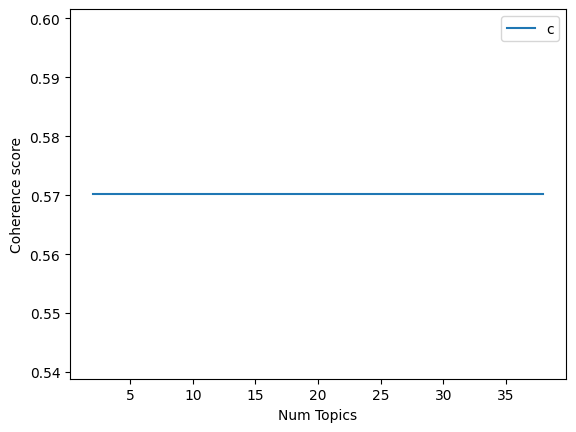

In [51]:
import matplotlib.pyplot as plt
limit=40; start=2; step=6;
x = range(start, limit, step)
plt.plot(x, coherence_values)
plt.xlabel("Num Topics")
plt.ylabel("Coherence score")
plt.legend(("coherence_values"), loc='best')
plt.show()
#seem

#**Running LDA using TF-IDF**

In [52]:
lda_model_tfidf = gensim.models.LdaMulticore(corpus_tfidf,
                                             num_topics=10,
                                             id2word = dictionary,
                                             passes = 2,
                                             workers=4)

/usr/local/lib/python3.12/dist-packages/gensim/models/ldamodel.py:847: RuntimeWarning: invalid value encountered in scalar divide
  perwordbound = self.bound(chunk, subsample_ratio=subsample_ratio) / (subsample_ratio * corpus_words)


In [53]:
for idx, topic in lda_model_tfidf.print_topics(-1):
    print("Topic: {} Word: {}".format(idx, topic))
    print("\n")

Topic: 0 Word: 0.143*"g" + 0.143*"v" + 0.143*"b" + 0.143*"p" + 0.143*"f" + 0.143*"k" + 0.143*"w"


Topic: 1 Word: 0.143*"g" + 0.143*"v" + 0.143*"b" + 0.143*"p" + 0.143*"f" + 0.143*"k" + 0.143*"w"


Topic: 2 Word: 0.143*"g" + 0.143*"v" + 0.143*"b" + 0.143*"p" + 0.143*"f" + 0.143*"k" + 0.143*"w"


Topic: 3 Word: 0.143*"g" + 0.143*"v" + 0.143*"b" + 0.143*"p" + 0.143*"f" + 0.143*"k" + 0.143*"w"


Topic: 4 Word: 0.143*"g" + 0.143*"v" + 0.143*"b" + 0.143*"p" + 0.143*"f" + 0.143*"k" + 0.143*"w"


Topic: 5 Word: 0.143*"g" + 0.143*"v" + 0.143*"b" + 0.143*"p" + 0.143*"f" + 0.143*"k" + 0.143*"w"


Topic: 6 Word: 0.143*"g" + 0.143*"v" + 0.143*"b" + 0.143*"p" + 0.143*"f" + 0.143*"k" + 0.143*"w"


Topic: 7 Word: 0.143*"g" + 0.143*"v" + 0.143*"b" + 0.143*"p" + 0.143*"f" + 0.143*"k" + 0.143*"w"


Topic: 8 Word: 0.143*"g" + 0.143*"v" + 0.143*"b" + 0.143*"p" + 0.143*"f" + 0.143*"k" + 0.143*"w"


Topic: 9 Word: 0.143*"g" + 0.143*"v" + 0.143*"b" + 0.143*"p" + 0.143*"f" + 0.143*"k" + 0.143*"w"




In [54]:
from gensim.models import CoherenceModel

coherence_model_lda_idf = CoherenceModel(model=lda_model_tfidf, texts=processed_docs, dictionary=dictionary, coherence='c_v')
coherence_model_lda_idf = coherence_model_lda_idf.get_coherence()
print('\nCoherence Score: ', coherence_model_lda_idf)


Coherence Score:  0.5702175402921047


#**classifying sample document using LDA Bag of Words model**

In [55]:
#original Text of sample document 4310
processed_docs[document_num]

[]

In [56]:
for index, score in sorted(lda_model[bow_corpus[document_num]], key=lambda tup: tup[1], reverse=True):
    print("\nScore: {}\t Topic: {}".format(score, lda_model.print_topic(index, 5)))


Score: 0.10000000149011612	 Topic: 0.143*"p" + 0.143*"g" + 0.143*"w" + 0.143*"f" + 0.143*"b"

Score: 0.10000000149011612	 Topic: 0.547*"w" + 0.204*"p" + 0.050*"b" + 0.050*"g" + 0.050*"v"

Score: 0.10000000149011612	 Topic: 0.143*"p" + 0.143*"b" + 0.143*"g" + 0.143*"f" + 0.143*"v"

Score: 0.10000000149011612	 Topic: 0.647*"v" + 0.059*"p" + 0.059*"b" + 0.059*"f" + 0.059*"w"

Score: 0.10000000149011612	 Topic: 0.869*"k" + 0.077*"p" + 0.011*"b" + 0.011*"g" + 0.011*"f"

Score: 0.10000000149011612	 Topic: 0.647*"g" + 0.059*"p" + 0.059*"b" + 0.059*"w" + 0.059*"v"

Score: 0.10000000149011612	 Topic: 0.647*"f" + 0.059*"p" + 0.059*"b" + 0.059*"g" + 0.059*"w"

Score: 0.10000000149011612	 Topic: 0.647*"b" + 0.059*"p" + 0.059*"w" + 0.059*"v" + 0.059*"g"

Score: 0.10000000149011612	 Topic: 0.143*"p" + 0.143*"w" + 0.143*"g" + 0.143*"b" + 0.143*"v"

Score: 0.10000000149011612	 Topic: 0.874*"p" + 0.021*"v" + 0.021*"b" + 0.021*"w" + 0.021*"g"


In [57]:
lda_model[bow_corpus[document_num]]

[(0, 0.1),
 (1, 0.1),
 (2, 0.1),
 (3, 0.1),
 (4, 0.1),
 (5, 0.1),
 (6, 0.1),
 (7, 0.1),
 (8, 0.1),
 (9, 0.1)]

In [58]:
sorted(lda_model[bow_corpus[document_num]], key=lambda tup: tup[1], reverse=True)

[(0, 0.1),
 (1, 0.1),
 (2, 0.1),
 (3, 0.1),
 (4, 0.1),
 (5, 0.1),
 (6, 0.1),
 (7, 0.1),
 (8, 0.1),
 (9, 0.1)]

In [59]:
lda_model.print_topic(index, 10)


'0.874*"p" + 0.021*"v" + 0.021*"b" + 0.021*"w" + 0.021*"g" + 0.021*"k" + 0.021*"f"'

#**classifying sample document using LDA TF-IDF model#**#

In [60]:
for index, score in sorted(lda_model_tfidf[bow_corpus[document_num]], key=lambda tup: tup[1], reverse=True):
    print("\nScore: {}\t Topic: {}".format(score, lda_model_tfidf.print_topic(index, 5)))


Score: 0.10000000149011612	 Topic: 0.143*"f" + 0.143*"p" + 0.143*"k" + 0.143*"g" + 0.143*"b"

Score: 0.10000000149011612	 Topic: 0.143*"f" + 0.143*"p" + 0.143*"k" + 0.143*"g" + 0.143*"b"

Score: 0.10000000149011612	 Topic: 0.143*"f" + 0.143*"p" + 0.143*"k" + 0.143*"g" + 0.143*"b"

Score: 0.10000000149011612	 Topic: 0.143*"f" + 0.143*"p" + 0.143*"k" + 0.143*"g" + 0.143*"b"

Score: 0.10000000149011612	 Topic: 0.143*"f" + 0.143*"p" + 0.143*"k" + 0.143*"g" + 0.143*"b"

Score: 0.10000000149011612	 Topic: 0.143*"f" + 0.143*"p" + 0.143*"k" + 0.143*"g" + 0.143*"b"

Score: 0.10000000149011612	 Topic: 0.143*"f" + 0.143*"p" + 0.143*"k" + 0.143*"g" + 0.143*"b"

Score: 0.10000000149011612	 Topic: 0.143*"f" + 0.143*"p" + 0.143*"k" + 0.143*"g" + 0.143*"b"

Score: 0.10000000149011612	 Topic: 0.143*"f" + 0.143*"p" + 0.143*"k" + 0.143*"g" + 0.143*"b"

Score: 0.10000000149011612	 Topic: 0.143*"f" + 0.143*"p" + 0.143*"k" + 0.143*"g" + 0.143*"b"


#**Testing model on unseen document**

In [61]:
unseen_document = "My name is Fentryca."

bow_vector = dictionary.doc2bow(preprocess(unseen_document))

for index, score in sorted(lda_model[bow_vector], key=lambda tup: tup[1], reverse=True):
    print("Score: {}\t Topic: {}".format(score, lda_model.print_topic(index, 5)))

Score: 0.10000000149011612	 Topic: 0.143*"p" + 0.143*"g" + 0.143*"w" + 0.143*"f" + 0.143*"b"
Score: 0.10000000149011612	 Topic: 0.547*"w" + 0.204*"p" + 0.050*"b" + 0.050*"g" + 0.050*"v"
Score: 0.10000000149011612	 Topic: 0.143*"p" + 0.143*"b" + 0.143*"g" + 0.143*"f" + 0.143*"v"
Score: 0.10000000149011612	 Topic: 0.647*"v" + 0.059*"p" + 0.059*"b" + 0.059*"f" + 0.059*"w"
Score: 0.10000000149011612	 Topic: 0.869*"k" + 0.077*"p" + 0.011*"b" + 0.011*"g" + 0.011*"f"
Score: 0.10000000149011612	 Topic: 0.647*"g" + 0.059*"p" + 0.059*"b" + 0.059*"w" + 0.059*"v"
Score: 0.10000000149011612	 Topic: 0.647*"f" + 0.059*"p" + 0.059*"b" + 0.059*"g" + 0.059*"w"
Score: 0.10000000149011612	 Topic: 0.647*"b" + 0.059*"p" + 0.059*"w" + 0.059*"v" + 0.059*"g"
Score: 0.10000000149011612	 Topic: 0.143*"p" + 0.143*"w" + 0.143*"g" + 0.143*"b" + 0.143*"v"
Score: 0.10000000149011612	 Topic: 0.874*"p" + 0.021*"v" + 0.021*"b" + 0.021*"w" + 0.021*"g"
